# EXERCICE 7 : REGRESSION LINEAIRE MULTIPLE AVEC REGULARISATION + VALIDATION CROISEE


Inspire de http://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_and_elasticnet.html


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


#### Génération de donnée synthétiques...

In [20]:

np.random.seed(31)

#... definition de n et p
n = 75
p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X
X = np.random.randn(n, p) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 
y = np.dot(X, beta) + (2.0 * np.random.normal(size=n))


# REMARQUE IMPORTANTE : y ne dépend que des variables i pour lesquelles beta[i] est non-nul


# ... coupe en deux les donnees en donnees d'apprentissage et donnes test
thresh=n // 2
X_train = X[thresh:]
y_train = y[thresh:]
X_test = X[:thresh]
y_test = y[:thresh]


#### Régression linéaire avec régularisation Lasso ...


In [56]:

from sklearn.linear_model import Lasso

alpha = 0.5 #0.36
lasso_regressor = Lasso(alpha=alpha)
lasso_regressor.fit(X_train, y_train)

y_pred_lasso = lasso_regressor.predict(X_test)
mse_score_lasso = mean_squared_error(y_test, y_pred_lasso)


####  Représentation du résultat


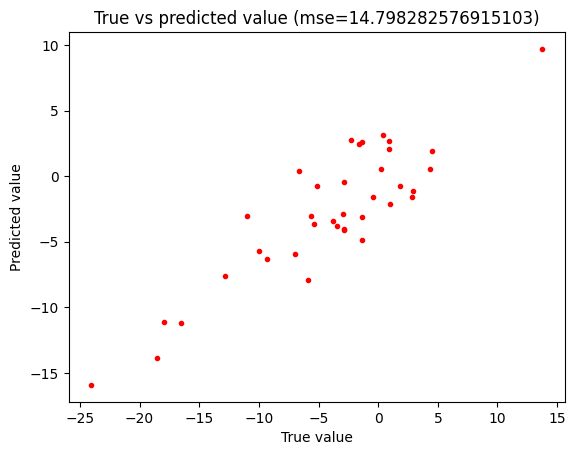

In [57]:
fig = plt.figure()
plt.plot(y_test, y_pred_lasso, 'r.')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.title('True vs predicted value (mse='+str(mse_score_lasso)+')')
plt.show()

# ATTENTION échelle des valeurs sur le plot, c'est pas suffisant de voir une diagonale

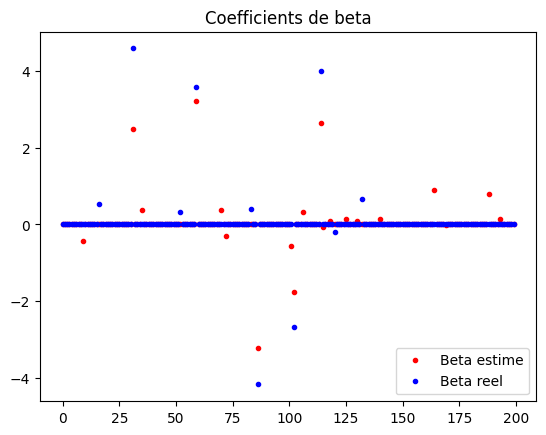

In [58]:

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()





### <span style="color:blue">QUESTION 1</span> :

Jouez l'exemple avec  n=1000, n=100, n=75, n=50, n=25. Qu'en deduisez vous sur l'impact du nombre d'observations

### <span style="color:blue">REPONSE 1</span> :

Augmenter le nombre d'observations n réduit le mse du modèle.



### <span style="color:blue">QUESTION 2</span> :

On garde n=75. Utilisez la validation croisee de type K-folds (typiquement 8-Folds) pour trouver le meilleur coefficient *alpha* au sens de la MSE. Pour chaque *alpha* testé, on gardera comme score la MSE moyenne obtenue sur tous les *folds*.

Remarque : la recherche d'un bon coefficient *alpha* pourra d'abord se faire sur une échelle exponentielle assez large (ex: 0.001, 0.01, 0.1, ...) puis être raffinée sur une échelle plus fine.  

### <span style="color:blue">REPONSE 2</span> :

In [59]:

from sklearn.model_selection import KFold

kf = KFold(8)
alphas = np.logspace(-2,0,10)

def evaluate_alphas(X, y, alphas, cv_splitter):
    mse_scores = []
    
    for alpha in alphas:
        fold_scores = []
        
        for train_index, val_index in cv_splitter.split(X):
            X_train, X_test = X[train_index], X[val_index]
            y_train, y_test = y[train_index], y[val_index]
            
            # Entraînement du modèle Lasso avec l'alpha courant
            model = Lasso(alpha=alpha)
            model.fit(X_train, y_train)
            
            # Prédiction et calcul de la MSE
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            fold_scores.append(mse)
        
        # MSE moyenne pour cet alpha sur tous les folds
        mean_mse = np.mean(fold_scores)
        mse_scores.append(mean_mse)
    
    return mse_scores

mse_scores = evaluate_alphas(X,y,alphas,kf)
for i in range(len(mse_scores)):
    print(mse_scores[i])
print(alphas)

# on trouve un alpha optimal d'environ 0.36

14.279992374168414
13.988981273010555
13.510175715317784
13.002024371137988
11.87407474085612
10.105905468495248
9.082863935567241
9.009881516952165
10.49668940157235
15.327897340073104
[0.01       0.01668101 0.02782559 0.04641589 0.07742637 0.12915497
 0.21544347 0.35938137 0.59948425 1.        ]


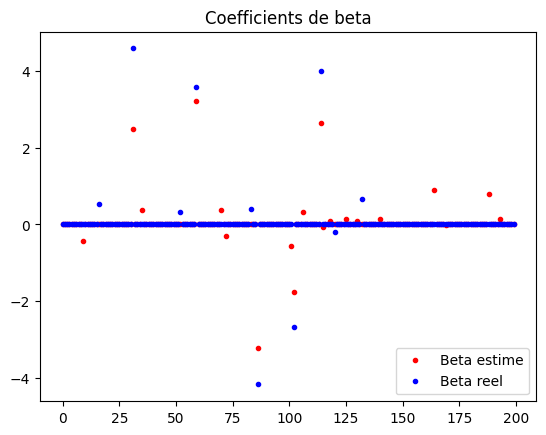

In [61]:
#représentation des coefficients estimés (lasso_regressor.coef_) et de ceux
#avec lesquels les données ont été simulées (beta)
model = Lasso(alpha=alpha)
model.fit(X_train, y_train)
fig = plt.figure()
plt.plot(model.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()


### <span style="color:blue">QUESTION 3</span> :

De manère alternative, codez et testez maintenant une sélection de type *forward* avec un critère de sélection *BIC*.

Comparez les résultats avec ceux obtenus à l'aide de la pénalisation LASSO.

### <span style="color:blue">REPONSE 3</span> :


In [75]:


from sklearn.linear_model import LinearRegression

#Critère de sélection BIC || sélection de type forward

def BIC(modele, X, y, q):
    n = len(X)
    mse = mean_squared_error(y, modele.predict(X))
    return n*np.log(mse) + np.log(n)*(q+1)


def forward_selection(X, y):
    vars_train = []
    vars_restantes = np.arange(len(X))
    q = 1
    best_bic = np.inf
    while len(vars_restantes)>0:    
        best_var_to_add = None
        print(q)

        for var in vars_restantes:
            vars_train = vars_train + [var]
            lr = LinearRegression()
            lr.fit(X[:,vars_train].reshape(-1, len(vars_train)), y)
            bic = BIC(lr, X[:,vars_restantes].reshape(-1, len(vars_restantes)), y, q)
            vars_train.remove(var)

            if bic<best_bic:
                # print("nouveau bestbic")
                best_bic = bic
                best_var_to_add = var

        if best_var_to_add != None:
            vars_train.append(best_var_to_add)
            index = np.where(vars_restantes == best_var_to_add)[0][0]
            np.delete(vars_restantes, index)
            q += 1
        else:
            break
    lr.fit(X[:, vars_train], y)    
    bic_mse_final = BIC(y, lr.predict(X[:,vars_restantes].reshape(-1, len(vars_restantes))))
    return bic_mse_final

print('mse forward selection with BIC criteria : ',forward_selection(X, y))    
    

1


ValueError: X has 75 features, but LinearRegression is expecting 1 features as input.